# 06 - Multi-Horizon Early-Warning Modeling

This notebook upgrades the modeling branch from a single day-30 classifier into a **research-focused multi-horizon early-warning study**.

## Research questions
1. How early can the project identify at-risk learners with useful recall?
2. Which horizon-model pair offers the strongest trade-off between intervention lead time and predictive quality?
3. Which feature groups create most of the modeling value?
4. Are the predicted probabilities calibrated well enough to support risk-tiered intervention?

## Scope
- Horizons: `day 7`, `day 14`, `day 21`, `day 30`
- Models: `Logistic Regression`, `Random Forest`, `XGBoost`
- Threshold rule: keep `validation recall >= 0.90`, then maximize `precision`, then `F2`, then `PR-AUC`
- Champion rule: compare all horizon-model pairs primarily on `PR-AUC`, then `F2`, and prefer an earlier horizon only when performance is close

In [1]:
from __future__ import annotations

import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 190)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (12, 6)

def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'data').exists() and (candidate / 'notebooks').exists() and (candidate / 'src').exists():
            return candidate
    raise FileNotFoundError('Could not locate the repository root from the current working directory.')

ROOT = find_repo_root()
PROCESSED = ROOT / 'data' / 'processed'
sys.path.append(str(ROOT))

from src.models import run_multi_horizon_study

HORIZONS = (7, 14, 21, 30)
ROOT, PROCESSED

(WindowsPath('D:/data_demo/Learning-Behavior-Analytics-and-Personalized-Learning-Path-Recommendation-for-At-Risk-Learners'),
 WindowsPath('D:/data_demo/Learning-Behavior-Analytics-and-Personalized-Learning-Path-Recommendation-for-At-Risk-Learners/data/processed'))

## 0. At-Risk Definition and Early Signal Diagnostics

Before training any model, the project defines precisely what "at-risk" means in this dataset.

### Label definition

A learner is labelled **at-risk = 1** if and only if `final_result ∈ {Fail, Withdrawn}`:

- **Withdrawn** — disengaged before course completion
- **Fail** — completed assessments but did not reach the pass threshold

This two-class collapse is intentional: both groups share early behavioral warning signs that an intervention can address **before the outcome is sealed**.

### Four observable early signals (day-7 snapshot)

| Signal group | Features used | At-risk pattern |
|---|---|---|
| Early engagement | `early_engagement_ratio`, `total_clicks_log` | Low interaction in the first week |
| Submission discipline | `avg_submission_delay`, `has_submission_by_horizon` | Late or missing submissions by day 7 |
| Early score quality | `avg_score`, `learning_risk_index` | Near-zero or absent scores in first assessments |
| Study consistency | `active_days_log`, `persistence_score` | Sporadic contact instead of regular activity |

The cell below validates that these four signal groups already **separate the two populations** at the earliest available horizon (day 7), before any model is trained.

,count,proportion
Group,,
At-risk,17208,52.8%
Non at-risk,15385,47.2%



Class imbalance ratio ≈ 1:1.1  →  class_weight='balanced' and scale_pos_weight are applied in all three candidate models.


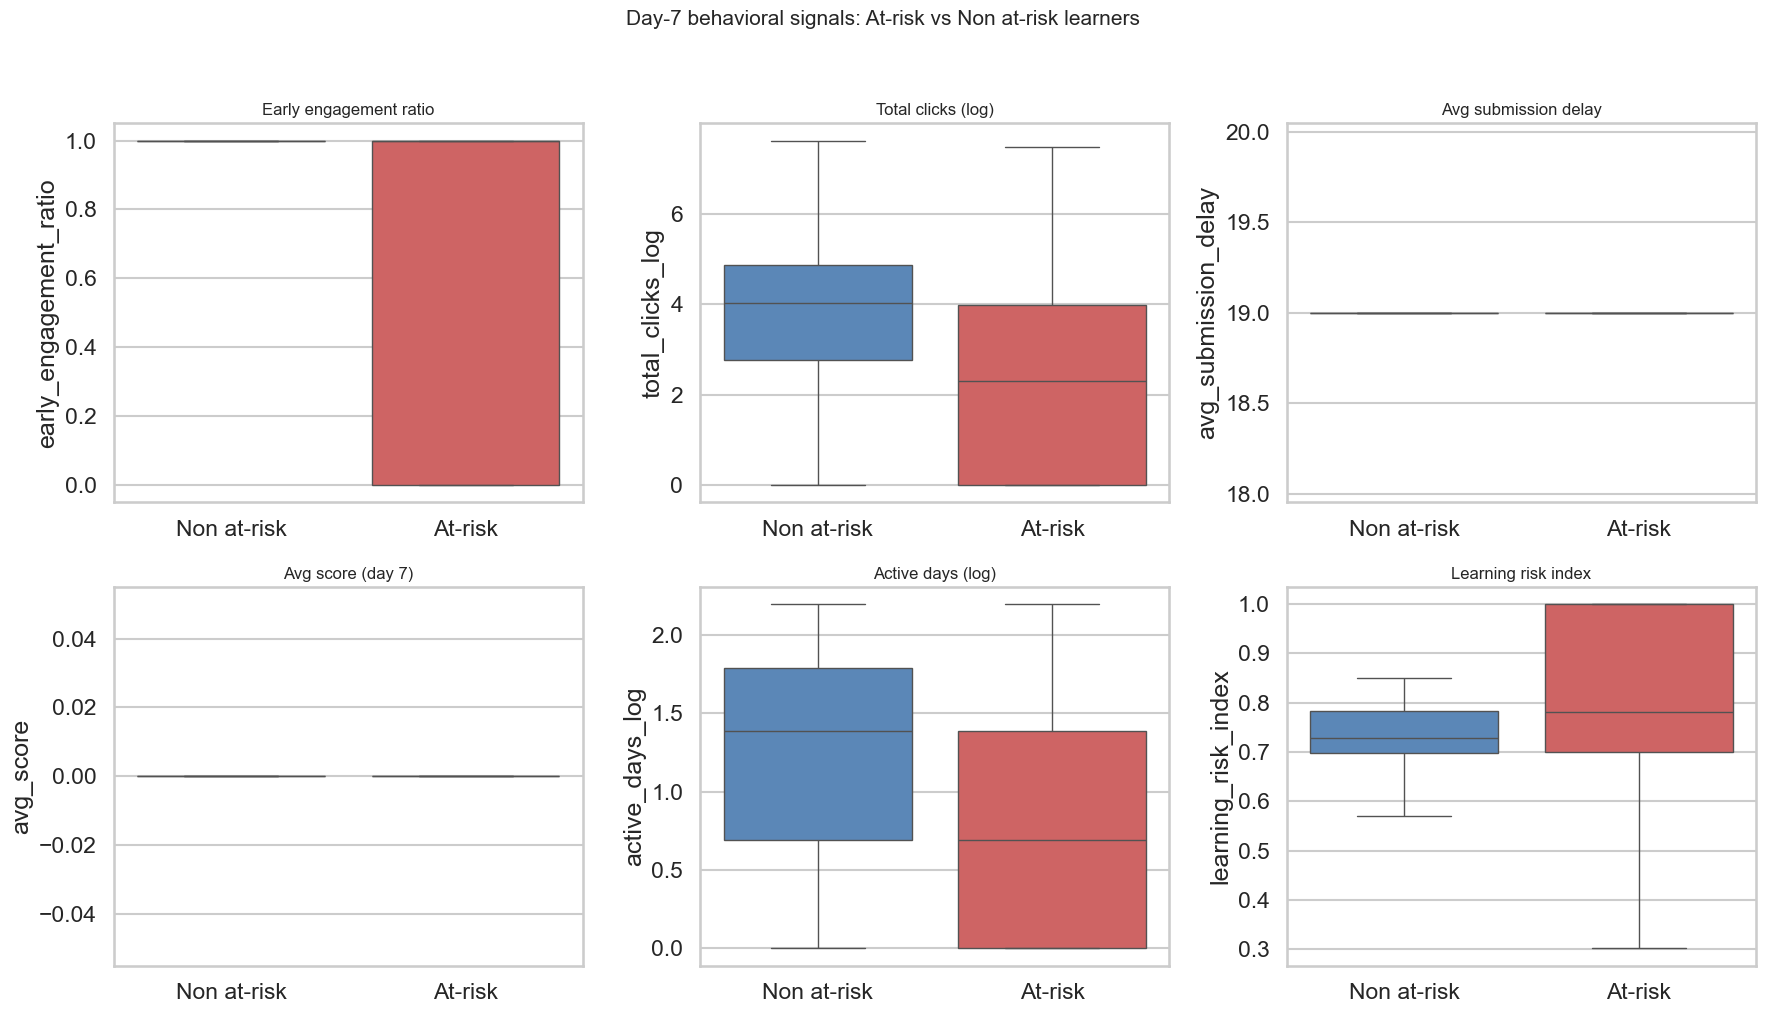

In [2]:
# At-risk signal diagnostics from the day-7 snapshot
day07 = pd.read_csv(PROCESSED / 'features_prediction_day07.csv')

signal_features = [
    'early_engagement_ratio', 'total_clicks_log',
    'avg_submission_delay', 'avg_score',
    'active_days_log', 'learning_risk_index',
]
signal_labels = [
    'Early engagement ratio', 'Total clicks (log)',
    'Avg submission delay', 'Avg score (day 7)',
    'Active days (log)', 'Learning risk index',
]

plot_data = day07.copy()
plot_data['Group'] = plot_data['at_risk'].map({0: 'Non at-risk', 1: 'At-risk'})
palette = {'Non at-risk': '#4C86C6', 'At-risk': '#E05252'}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (feat, label) in enumerate(zip(signal_features, signal_labels)):
    if feat not in day07.columns:
        axes[i].set_visible(False)
        continue
    sns.boxplot(
        data=plot_data, x='Group', y=feat,
        palette=palette, showfliers=False, ax=axes[i],
    )
    axes[i].set_title(label, fontsize=12)
    axes[i].set_xlabel('')

fig.suptitle('Day-7 behavioral signals: At-risk vs Non at-risk learners', fontsize=15, y=1.02)
plt.tight_layout()

# Class balance summary
counts = day07['at_risk'].value_counts().rename({0: 'Non at-risk', 1: 'At-risk'})
total = counts.sum()
balance_df = pd.DataFrame({
    'count': counts,
    'proportion': (counts / total).map('{:.1%}'.format),
}).rename_axis('Group')
display(balance_df)
print(
    f"\nClass imbalance ratio ≈ 1:{counts[0]/counts[1]:.1f}"
    "  →  class_weight='balanced' and scale_pos_weight are applied in all three candidate models."
)

## 1. Run the multi-horizon study

The heavy pipeline now lives in `src/models/multi_horizon_early_warning.py`.
The notebook remains responsible for the research narrative, visual checks, and reporting interpretation.

In [3]:
results = run_multi_horizon_study(
    processed_dir=PROCESSED,
    horizons=HORIZONS,
    ablation_horizons=(14, 30),
    random_state=42,
    target_recall=0.90,
    write_outputs=True,
)

display(results.split_summary)

print('Champion horizon-model pair:')
display(results.champion_row.to_frame(name='value'))

,split,rows,at_risk_rate
0,test,6519,0.5280
1,train,19555,0.5279
2,validation,6519,0.5280


Champion horizon-model pair:


,value
threshold,0.2500
accuracy,0.6716
precision,0.6284
recall,0.9250
f1,0.7484
f2,0.8452
roc_auc,0.8306
pr_auc,0.8639
brier_score,0.1662
tn,1194


## 2. Model comparison across horizons

A fair comparison needs the same enrollment split across all horizons.
That way, the differences below come from the **amount of information available by each day cutoff**, not from a moving test sample.

In [4]:
selected_cols = [
    'horizon_day', 'model', 'threshold', 'precision', 'recall', 'f2', 'roc_auc', 'pr_auc',
    'is_best_for_horizon', 'is_earliest_useful_horizon',
]
display(results.selected_operating_points[selected_cols].sort_values(['horizon_day', 'model']))

comparison_view = results.model_horizon_comparison[[
    'horizon_day', 'model', 'selected_threshold',
    'validation_precision', 'validation_recall', 'validation_f2', 'validation_pr_auc',
    'test_precision', 'test_recall', 'test_f2', 'test_pr_auc',
]].sort_values(['horizon_day', 'model'])
display(comparison_view)

,horizon_day,model,threshold,precision,recall,f2,roc_auc,pr_auc,is_best_for_horizon,is_earliest_useful_horizon
0,7,Logistic Regression,0.2500,0.5771,0.9393,0.8345,0.7376,0.7591,True,True
1,7,Random Forest,0.3000,0.5808,0.9253,0.8272,0.7334,0.7565,False,False
2,7,XGBoost,0.3000,0.5927,0.9062,0.8195,0.7423,0.7654,False,False
3,14,Logistic Regression,0.2500,0.5828,0.9259,0.8284,0.7584,0.7907,False,False
4,14,Random Forest,0.3000,0.5929,0.9137,0.8245,0.7568,0.7915,False,False
5,14,XGBoost,0.2500,0.5766,0.9346,0.8314,0.7658,0.8008,True,False
6,21,Logistic Regression,0.2500,0.6037,0.9169,0.8307,0.7752,0.8091,False,False
7,21,Random Forest,0.3000,0.6237,0.9024,0.8284,0.7978,0.8334,False,False
8,21,XGBoost,0.2500,0.6113,0.9303,0.8424,0.8094,0.8438,True,False
9,30,Logistic Regression,0.2500,0.6179,0.9102,0.8316,0.7936,0.8263,False,False


,horizon_day,model,selected_threshold,validation_precision,validation_recall,validation_f2,validation_pr_auc,test_precision,test_recall,test_f2,test_pr_auc
0,7,Logistic Regression,0.2500,0.5771,0.9393,0.8345,0.7591,0.5791,0.9451,0.8391,0.7730
1,7,Random Forest,0.3000,0.5808,0.9253,0.8272,0.7565,0.5872,0.9326,0.8344,0.7736
2,7,XGBoost,0.3000,0.5927,0.9062,0.8195,0.7654,0.5974,0.9152,0.8272,0.7770
3,14,Logistic Regression,0.2500,0.5828,0.9259,0.8284,0.7907,0.5909,0.9314,0.8352,0.8041
4,14,Random Forest,0.3000,0.5929,0.9137,0.8245,0.7915,0.6002,0.9213,0.8322,0.8067
5,14,XGBoost,0.2500,0.5766,0.9346,0.8314,0.8008,0.5852,0.9474,0.8431,0.8111
6,21,Logistic Regression,0.2500,0.6037,0.9169,0.8307,0.8091,0.6075,0.9332,0.8428,0.8214
7,21,Random Forest,0.3000,0.6237,0.9024,0.8284,0.8334,0.6316,0.9094,0.8358,0.8468
8,21,XGBoost,0.2500,0.6113,0.9303,0.8424,0.8438,0.6127,0.9387,0.8484,0.8541
9,30,Logistic Regression,0.2500,0.6179,0.9102,0.8316,0.8263,0.6221,0.9227,0.8414,0.8423


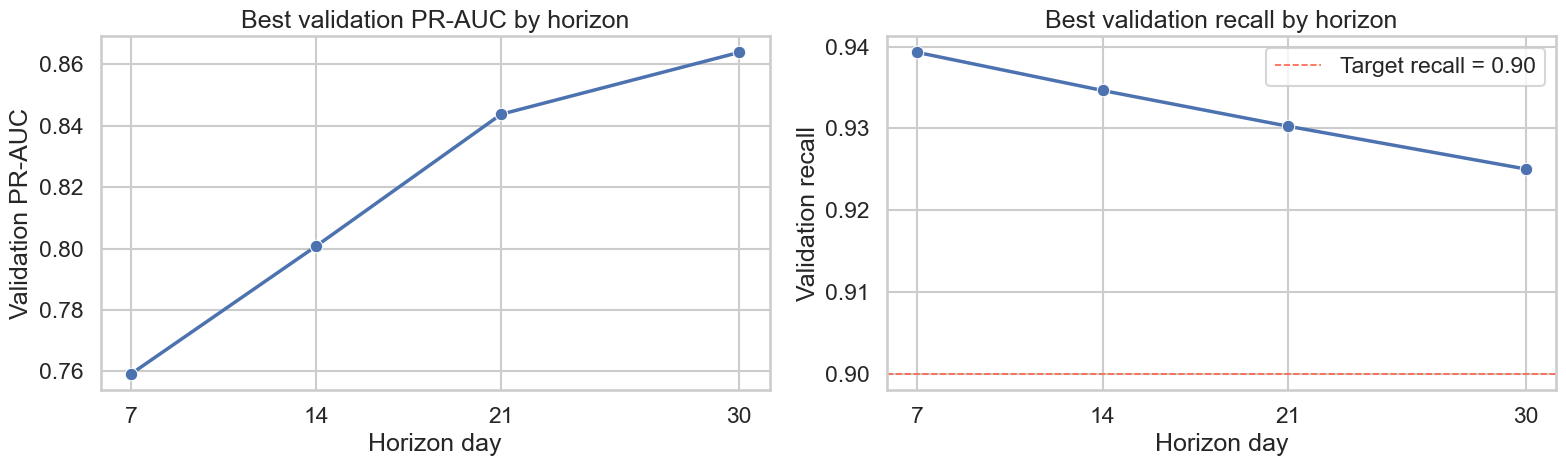

In [5]:
plot_df = results.model_horizon_comparison.copy()
best_only = plot_df.merge(
    results.selected_operating_points[['horizon_day', 'model', 'is_best_for_horizon']],
    on=['horizon_day', 'model'],
    how='left',
)
best_only = best_only.loc[best_only['is_best_for_horizon']].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.lineplot(data=best_only, x='horizon_day', y='validation_pr_auc', marker='o', linewidth=2.5, ax=axes[0])
axes[0].set_title('Best validation PR-AUC by horizon')
axes[0].set_xlabel('Horizon day')
axes[0].set_ylabel('Validation PR-AUC')
axes[0].set_xticks(list(HORIZONS))

sns.lineplot(data=best_only, x='horizon_day', y='validation_recall', marker='o', linewidth=2.5, ax=axes[1])
axes[1].axhline(0.90, color='tomato', linestyle='--', linewidth=1.2, label='Target recall = 0.90')
axes[1].set_title('Best validation recall by horizon')
axes[1].set_xlabel('Horizon day')
axes[1].set_ylabel('Validation recall')
axes[1].set_xticks(list(HORIZONS))
axes[1].legend()

plt.tight_layout()

## 3. Threshold tuning and the champion operating point

The project does **not** use the default `0.50` classification threshold.
Instead, each horizon-model pair gets its own validation-selected operating point under the recall-first rule.

,split,horizon_day,model,threshold,accuracy,precision,recall,f1,f2,roc_auc,pr_auc,brier_score
0,validation,30,XGBoost,0.2500,0.6716,0.6284,0.9250,0.7484,0.8452,0.8306,0.8639,0.1662
1,test,30,XGBoost,0.2500,0.6731,0.6281,0.9340,0.7511,0.8511,0.8477,0.8768,0.1576


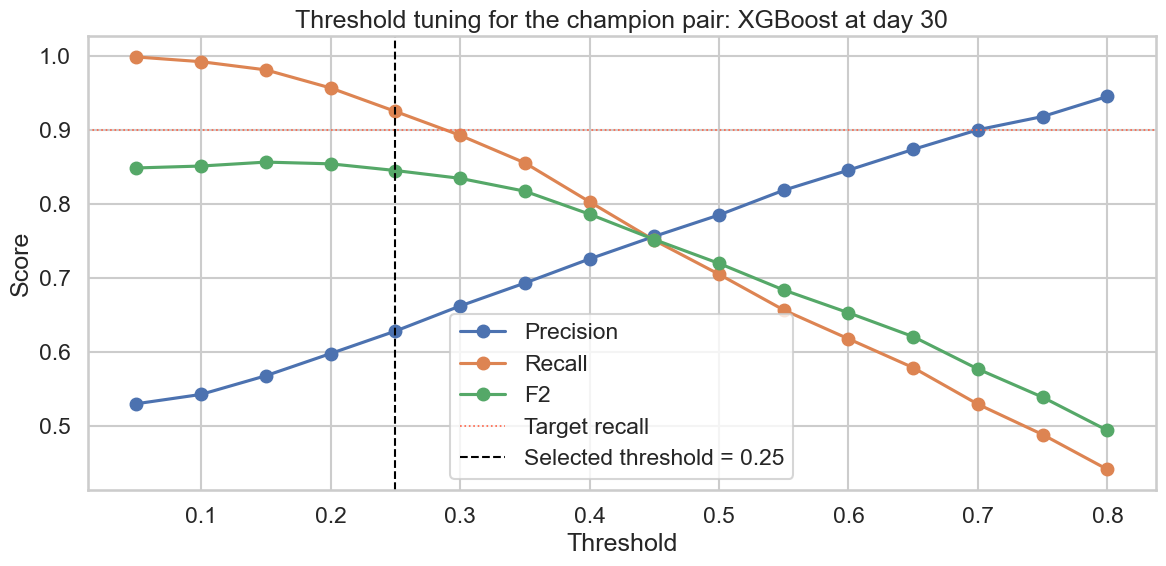

In [6]:
champion_horizon = int(results.champion_row['horizon_day'])
champion_model = str(results.champion_row['model'])
selected_threshold = float(results.champion_row['threshold'])
champion_threshold_curve = results.threshold_search_by_horizon.loc[
    (results.threshold_search_by_horizon['horizon_day'].eq(champion_horizon))
    & (results.threshold_search_by_horizon['model'].eq(champion_model))
].copy()

fig, ax = plt.subplots(figsize=(12, 6))
for metric in ['precision', 'recall', 'f2']:
    ax.plot(champion_threshold_curve['threshold'], champion_threshold_curve[metric], marker='o', label=metric.title())
ax.axhline(0.90, color='tomato', linestyle=':', linewidth=1.2, label='Target recall')
ax.axvline(selected_threshold, color='black', linestyle='--', linewidth=1.5, label=f'Selected threshold = {selected_threshold:.2f}')
ax.set_title(f'Threshold tuning for the champion pair: {champion_model} at day {champion_horizon}')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.legend()
plt.tight_layout()

display(results.champion_test_metrics[['split', 'horizon_day', 'model', 'threshold', 'accuracy', 'precision', 'recall', 'f1', 'f2', 'roc_auc', 'pr_auc', 'brier_score']])

## 4. Calibration and risk bands

Binary predictions alone are not enough for intervention planning.
This section checks whether the champion model family produces probabilities that remain ordered and interpretable across horizons, then maps the final champion probabilities into operational risk bands.

,risk_band,n,actual_at_risk_rate,average_predicted_probability,risk_band_method,band_edges
0,Low,1400,0.1621,0.1589,fixed_cutpoints,"[-inf, 0.25, 0.5, 0.75, inf]"
1,Medium,1995,0.3434,0.3663,fixed_cutpoints,"[-inf, 0.25, 0.5, 0.75, inf]"
2,High,1235,0.6324,0.6231,fixed_cutpoints,"[-inf, 0.25, 0.5, 0.75, inf]"
3,Critical,1889,0.9259,0.9236,fixed_cutpoints,"[-inf, 0.25, 0.5, 0.75, inf]"


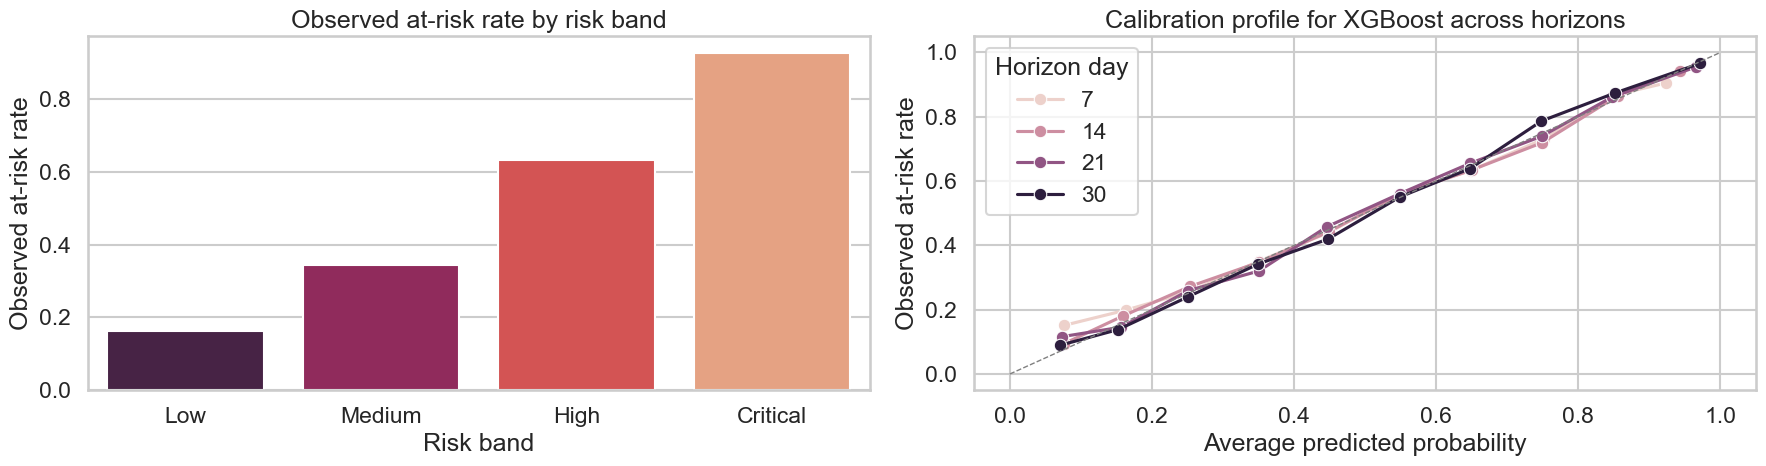

In [7]:
display(results.risk_band_summary)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.barplot(data=results.risk_band_summary, x='risk_band', y='actual_at_risk_rate', palette='rocket', ax=axes[0])
axes[0].set_title('Observed at-risk rate by risk band')
axes[0].set_xlabel('Risk band')
axes[0].set_ylabel('Observed at-risk rate')

calibration_plot = results.calibration_summary.copy()
sns.lineplot(data=calibration_plot, x='avg_predicted_probability', y='observed_at_risk_rate', hue='horizon_day', marker='o', ax=axes[1])
axes[1].plot([0, 1], [0, 1], linestyle='--', color='grey', linewidth=1)
axes[1].set_title(f'Calibration profile for {champion_model} across horizons')
axes[1].set_xlabel('Average predicted probability')
axes[1].set_ylabel('Observed at-risk rate')
axes[1].legend(title='Horizon day')

plt.tight_layout()

## 5. Ablation study

Ablation is run on `day 14` and `day 30` to answer a sharper research question:
**which feature group creates most of the value, and how does that change when the model sees more course history?**

,horizon_day,model,feature_group,feature_count,selected_threshold,validation_precision,validation_recall,validation_f2,validation_roc_auc,validation_pr_auc,test_precision,test_recall,test_f2,test_roc_auc,test_pr_auc
2,14,XGBoost,assessment only,7,0.5500,0.5526,0.9494,0.8302,0.5450,0.5538,0.5555,0.9529,0.8336,0.5506,0.5565
0,14,XGBoost,demographics only,20,0.3500,0.5501,0.9431,0.8252,0.6541,0.6728,0.5505,0.9431,0.8254,0.6513,0.6668
3,14,XGBoost,engagement + assessment,14,0.3000,0.5713,0.9317,0.8273,0.7189,0.7475,0.5780,0.9375,0.8338,0.7429,0.7683
1,14,XGBoost,engagement only,7,0.3000,0.5651,0.9317,0.8247,0.7095,0.7409,0.5687,0.9431,0.8333,0.7317,0.7586
4,14,XGBoost,full feature set,35,0.2500,0.5766,0.9346,0.8314,0.7658,0.8008,0.5852,0.9474,0.8431,0.7828,0.8111
7,30,XGBoost,assessment only,7,0.2500,0.5830,0.9433,0.8396,0.7371,0.7203,0.5890,0.9477,0.8448,0.7620,0.7420
5,30,XGBoost,demographics only,20,0.3500,0.5501,0.9431,0.8252,0.6541,0.6728,0.5505,0.9431,0.8254,0.6513,0.6668
8,30,XGBoost,engagement + assessment,14,0.2500,0.6065,0.9282,0.8392,0.7975,0.8267,0.6155,0.9390,0.8497,0.8233,0.8467
6,30,XGBoost,engagement only,7,0.3000,0.5852,0.9035,0.8149,0.7438,0.7865,0.5895,0.9126,0.8224,0.7659,0.8031
9,30,XGBoost,full feature set,35,0.2500,0.6284,0.9250,0.8452,0.8306,0.8639,0.6281,0.9340,0.8511,0.8477,0.8768


,horizon_day,feature_group,delta_test_precision_vs_full,delta_test_recall_vs_full,delta_test_f2_vs_full,delta_test_roc_auc_vs_full,delta_test_pr_auc_vs_full
2,14,assessment only,-0.0298,0.0055,-0.0094,-0.2322,-0.2546
0,14,demographics only,-0.0347,-0.0044,-0.0177,-0.1315,-0.1443
3,14,engagement + assessment,-0.0072,-0.0099,-0.0093,-0.0399,-0.0428
1,14,engagement only,-0.0166,-0.0044,-0.0097,-0.0511,-0.0525
4,14,full feature set,0.0000,0.0000,0.0000,0.0000,0.0000
7,30,assessment only,-0.0390,0.0137,-0.0063,-0.0857,-0.1347
5,30,demographics only,-0.0775,0.0090,-0.0257,-0.1964,-0.2099
8,30,engagement + assessment,-0.0126,0.0049,-0.0014,-0.0244,-0.0301
6,30,engagement only,-0.0385,-0.0215,-0.0287,-0.0819,-0.0737
9,30,full feature set,0.0000,0.0000,0.0000,0.0000,0.0000


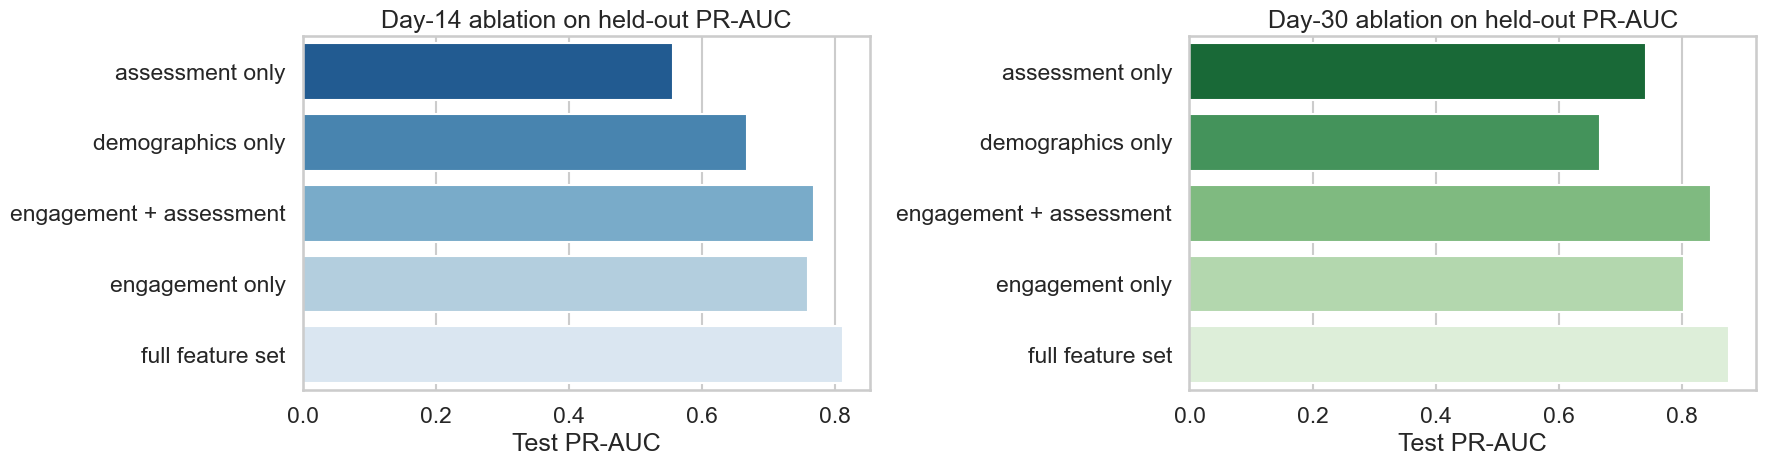

In [8]:
display(results.ablation_results.sort_values(['horizon_day', 'feature_group']))

ablation_plot = results.ablation_results.copy()
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
sns.barplot(data=ablation_plot.loc[ablation_plot['horizon_day'].eq(14)], x='test_pr_auc', y='feature_group', palette='Blues_r', ax=axes[0])
axes[0].set_title('Day-14 ablation on held-out PR-AUC')
axes[0].set_xlabel('Test PR-AUC')
axes[0].set_ylabel('')

sns.barplot(data=ablation_plot.loc[ablation_plot['horizon_day'].eq(30)], x='test_pr_auc', y='feature_group', palette='Greens_r', ax=axes[1])
axes[1].set_title('Day-30 ablation on held-out PR-AUC')
axes[1].set_xlabel('Test PR-AUC')
axes[1].set_ylabel('')

plt.tight_layout()

display(results.ablation_gain_summary[['horizon_day', 'feature_group', 'delta_test_precision_vs_full', 'delta_test_recall_vs_full', 'delta_test_f2_vs_full', 'delta_test_roc_auc_vs_full', 'delta_test_pr_auc_vs_full']].sort_values(['horizon_day', 'feature_group']))

## 6. Global interpretation and error diagnostics

The project keeps interpretation deliberately light and defensible:
- native importance from the champion model,
- permutation importance on validation ranking quality,
- concrete false-positive / false-negative inspection.

,feature,native_importance,permutation_importance_mean,permutation_importance_std,original_feature_name,horizon_day,model,importance_rank
0,avg_score,0.0833,0.0462,0.0027,avg_score,30,XGBoost,1
1,days_since_last,0.2262,0.0374,0.0035,days_since_last,30,XGBoost,2
2,studied_credits,0.0635,0.0364,0.0023,studied_credits,30,XGBoost,3
3,avg_submission_delay,0.0336,0.0178,0.0010,avg_submission_delay,30,XGBoost,4
4,assessment_discipline,0.0290,0.0104,0.0011,assessment_discipline,30,XGBoost,5
5,highest_education_Lower_Than_A_Level,0.0498,0.0081,0.0007,highest_education_Lower Than A Level,30,XGBoost,6
6,active_days_log,0.0755,0.0061,0.0009,active_days_log,30,XGBoost,7
7,gender_M,0.0268,0.0041,0.0005,gender_M,30,XGBoost,8
8,completion_ratio,0.0460,0.0040,0.0004,completion_ratio,30,XGBoost,9
9,num_of_prev_attempts,0.0216,0.0027,0.0004,num_of_prev_attempts,30,XGBoost,10


,id_student,code_module,code_presentation,horizon_day,model,selected_threshold,y_true,risk_probability,y_pred,risk_band,risk_band_method,final_result,cluster_label,rule_segment,recommended_path,action_1,action_2,action_3,recommendation_score,prediction_outcome,days_since_last,avg_score,avg_submission_delay,completion_ratio,num_submitted,total_clicks_log,active_days_log,early_engagement_ratio,assessment_discipline,persistence_score,learning_risk_index,distance_to_threshold
0,530852,FFF,2013B,30,XGBoost,0.2500,1,0.2497,0,Low,fixed_cutpoints,Withdrawn,Steady Progressors,Focused Achievers,Early Start Path,Move more of your study activity into the firs...,NaN,NaN,77.2000,False Negative,0.0000,94.0000,1.0000,1.0000,1.0000,6.5820,3.2189,0.3315,0.5365,0.7742,0.4221,-0.0003
1,685000,BBB,2014J,30,XGBoost,0.2500,1,0.2493,0,Low,fixed_cutpoints,Withdrawn,Sporadic Explorers,Steady Progressors,Consistency Building Path,Spread study activity across more days each we...,NaN,NaN,67.2000,False Negative,4.0000,1.0000,2.0000,0.5000,1.0000,5.7333,2.3026,0.5000,0.2885,0.3750,0.8170,-0.0007
2,560067,FFF,2013B,30,XGBoost,0.2500,1,0.2493,0,Low,fixed_cutpoints,Fail,Steady Progressors,Focused Achievers,Mastery Improvement Path,Prioritize accuracy and revision quality befor...,Spread study activity across more days each we...,Move more of your study activity into the firs...,80.1000,False Negative,6.0000,100.0000,1.0000,1.0000,1.0000,6.0234,2.7726,0.5728,0.5365,0.6250,0.4216,-0.0007
3,298777,DDD,2014J,30,XGBoost,0.2500,1,0.2493,0,Low,fixed_cutpoints,Fail,Steady Progressors,Steady Progressors,Assessment Recovery Path,Submit all available assessments in the first ...,Follow a fixed weekly assessment schedule and ...,Use more focused study sessions on the days yo...,79.8000,False Negative,4.0000,85.0000,3.0000,0.5000,1.0000,5.3132,2.7726,0.7376,0.2904,0.5769,0.5046,-0.0007
4,609383,EEE,2014B,30,XGBoost,0.2500,1,0.2492,0,Low,fixed_cutpoints,Fail,Sporadic Explorers,Sporadic Explorers,Assessment Recovery Path,Submit all available assessments in the first ...,Move more of your study activity into the firs...,NaN,70.5000,False Negative,0.0000,0.0000,1.0000,0.0000,0.0000,6.2265,2.5649,0.4673,0.0000,0.3871,0.8566,-0.0008
5,115452,BBB,2014B,30,XGBoost,0.2500,1,0.2491,0,Low,fixed_cutpoints,Fail,Steady Progressors,Steady Progressors,Early Start Path,Move more of your study activity into the firs...,Submit all available assessments in the first ...,Follow a fixed weekly assessment schedule and ...,76.3000,False Negative,0.0000,86.0000,1.0000,0.5000,1.0000,5.3519,2.8904,0.1476,0.2865,0.5667,0.5629,-0.0009
6,189178,DDD,2014B,30,XGBoost,0.2500,1,0.2487,0,Low,fixed_cutpoints,Fail,Steady Progressors,Focused Achievers,Mastery Improvement Path,Prioritize accuracy and revision quality befor...,Spread study activity across more days each we...,Move more of your study activity into the firs...,76.7000,False Negative,0.0000,85.0000,0.0000,1.0000,1.0000,6.8554,3.3322,0.5411,0.5346,0.8710,0.4004,-0.0013
7,229326,BBB,2014J,30,XGBoost,0.2500,1,0.2481,0,Low,fixed_cutpoints,Withdrawn,Steady Progressors,Steady Progressors,Assessment Recovery Path,Submit all available assessments in the first ...,Follow a fixed weekly assessment schedule and ...,Spread study activity across more days each we...,77.1000,False Negative,3.0000,100.0000,2.0000,0.5000,1.0000,5.7038,2.5649,0.8528,0.2885,0.4615,0.4678,-0.0019
8,627367,DDD,2014B,30,XGBoost,0.2500,1,0.2480,0,Low,fixed_cutpoints,Withdrawn,Steady Progressors,Focused Achievers,Mastery Improvement Path,Prioritize accuracy and revision quality befor...,NaN,NaN,79.5000,False Negative,0.0000,75.0000,1.0000,1.0000,1.0000,5.9296,3.0445,0.5493,0.5365,0.6667,0.4920,-0.0020
9,572213,FFF,2013J,30,XGBoost,0.2500,1,0.2478,0,Low,fixed_cutpoints,Withdrawn,Steady Progressors,Steady Progressors,Consistency Building Path,Spread study activity across more days each we...,NaN,NaN,77.3000,False Negative,0.0000,80.0000,1.0000,1.0000,1.0000,5.2257,2.5649,0.5892,0.5365,0.

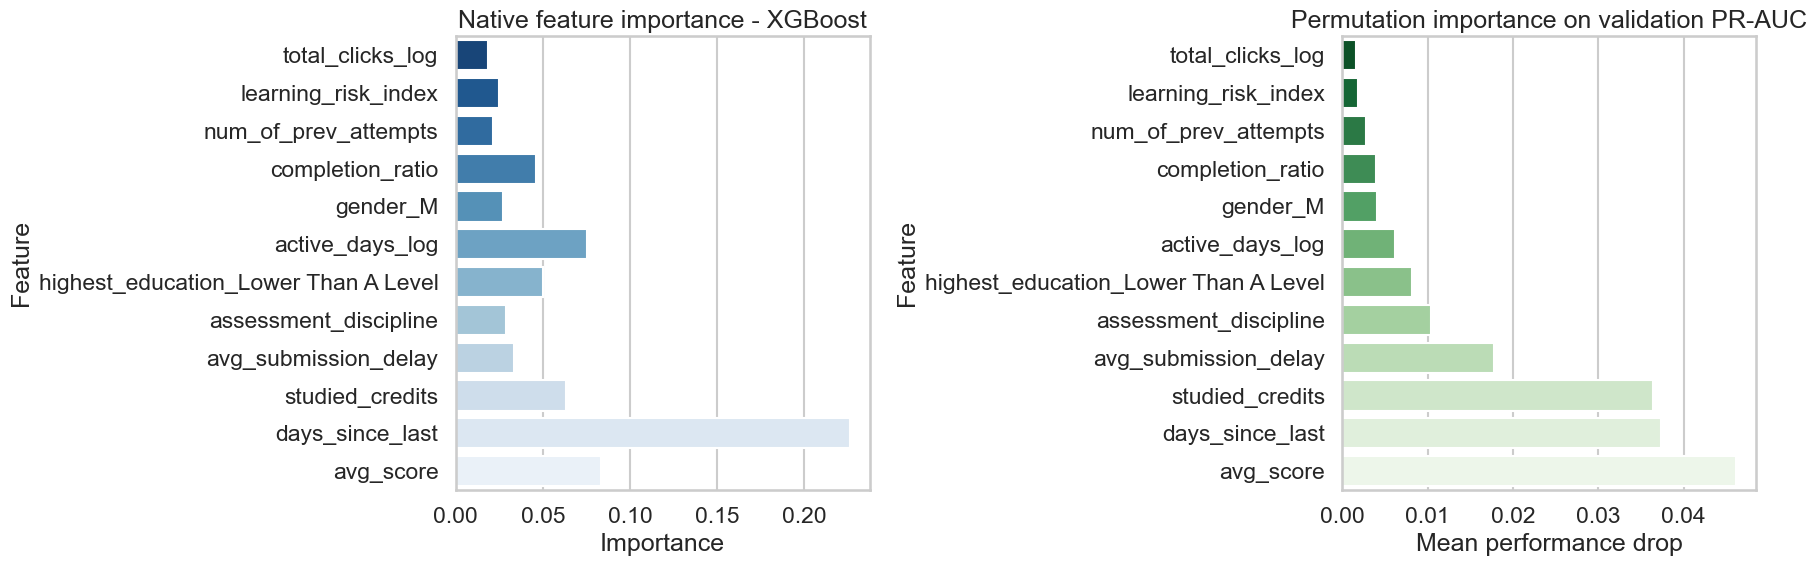

In [9]:
display(results.model_feature_importance.head(15))

top_importance = results.model_feature_importance.head(12).sort_values('permutation_importance_mean', ascending=True)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.barplot(data=top_importance, x='native_importance', y='original_feature_name', palette='Blues_r', ax=axes[0])
axes[0].set_title(f'Native feature importance - {champion_model}')
axes[0].set_xlabel('Importance')
axes[0].set_ylabel('Feature')

sns.barplot(data=top_importance, x='permutation_importance_mean', y='original_feature_name', palette='Greens_r', ax=axes[1])
axes[1].set_title('Permutation importance on validation PR-AUC')
axes[1].set_xlabel('Mean performance drop')
axes[1].set_ylabel('Feature')

plt.tight_layout()

display(results.error_analysis_samples.head(20))

## 7. Segment and outcome diagnostics for the dashboard

Even though segmentation is no longer a modeling input, it still remains useful for diagnostic slicing and Power BI storytelling.

,cluster_label,n,actual_at_risk_rate,predicted_positive_rate,average_risk_probability,precision,recall,accuracy
1,Inactive Drop-offs,"1,015.0000",0.9300,1.0000,0.9377,0.9300,1.0000,0.9300
2,Sporadic Explorers,"1,683.0000",0.6156,0.9234,0.6256,0.6525,0.9788,0.6661
3,Steady Progressors,"3,400.0000",0.3885,0.6874,0.3908,0.4947,0.8751,0.6041
0,Focused Achievers,421.0000,0.3349,0.5059,0.3181,0.4742,0.7163,0.6390


,final_result,n,predicted_positive_rate,average_risk_probability
0,Distinction,601,0.4376,0.2558
1,Pass,2476,0.6628,0.3609
2,Fail,1425,0.9144,0.6098
3,Withdrawn,2017,0.9479,0.7690


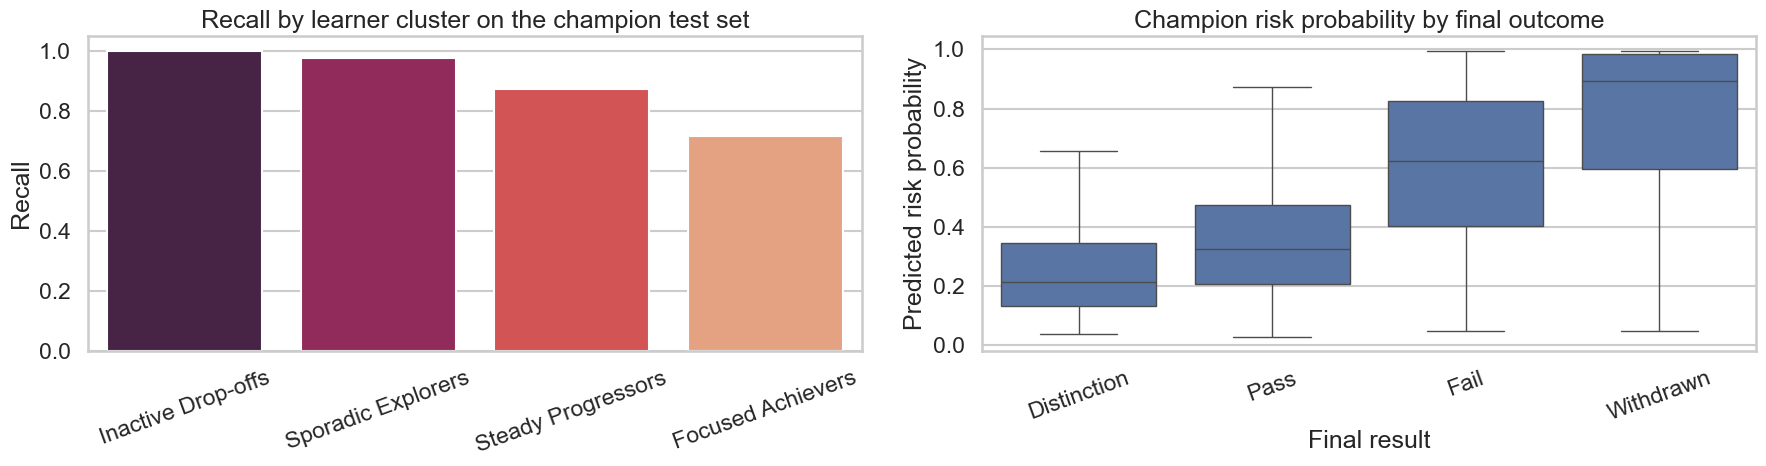

In [10]:
display(results.segment_model_performance)
display(results.outcome_risk_summary)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
sns.barplot(data=results.segment_model_performance, x='cluster_label', y='recall', palette='rocket', ax=axes[0])
axes[0].set_title('Recall by learner cluster on the champion test set')
axes[0].set_xlabel('')
axes[0].set_ylabel('Recall')
axes[0].tick_params(axis='x', rotation=20)

sns.boxplot(data=results.champion_test_predictions, x='final_result', y='risk_probability', order=['Distinction', 'Pass', 'Fail', 'Withdrawn'], showfliers=False, ax=axes[1])
axes[1].set_title('Champion risk probability by final outcome')
axes[1].set_xlabel('Final result')
axes[1].set_ylabel('Predicted risk probability')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()

## 8. At-Risk Targeted Intervention Playbook

Risk band scores from Section 4 drive a **tiered intervention protocol** designed specifically for the at-risk population.

### Design principles

| Pillar | Implementation |
|---|---|
| **Shorter paths** | At-risk learners are matched to `Re-Engagement Path` or `Assessment Recovery Path` — both use fewer required actions than the default curriculum |
| **Accessible resources** | `activity_recommendation_1` targets `Core learning content` and `Course homepage` before collaborative or complex resource types |
| **Reordered content** | Actions are sequenced by the learner's weakest `gap_feature_*` rather than a fixed module order |
| **Intervention priority** | `Critical` band → immediate advisor contact; `High` → targeted alert; `Medium` → automated nudge; `Low` → standard path |

The analysis below uses the champion test set predictions (XGBoost, day 30) merged with recommendation data to show how the playbook distributes across the at-risk population.

Recommended paths for at-risk learners (test set) by risk band:


risk_band,Low,Medium,High,Critical
recommended_path,,,,
Assessment Discipline Path,9,5,2,1
Assessment Recovery Path,78,126,85,100
Consistency Building Path,31,196,256,1066
Early Start Path,52,183,204,205
Focused Study Path,12,34,26,31
Mastery Improvement Path,44,109,170,157
Re-Engagement Path,1,32,38,189



Top intervention actions per risk band (at-risk learners):

  [Low]
    ( 123x) Submit all available assessments in the first month and avoid missing deadlines.
    ( 119x) Move more of your study activity into the first two weeks of the course.
    (  97x) Spread study activity across more days each week instead of short bursts.

  [Medium]
    ( 396x) Spread study activity across more days each week instead of short bursts.
    ( 376x) Submit all available assessments in the first month and avoid missing deadlines.
    ( 300x) Move more of your study activity into the first two weeks of the course.

  [High]
    ( 470x) Spread study activity across more days each week instead of short bursts.
    ( 372x) Submit all available assessments in the first month and avoid missing deadlines.
    ( 361x) Prioritize accuracy and revision quality before increasing workload volume.

  [Critical]
    (1341x) Submit all available assessments in the first month and avoid missing deadlines.
    (13

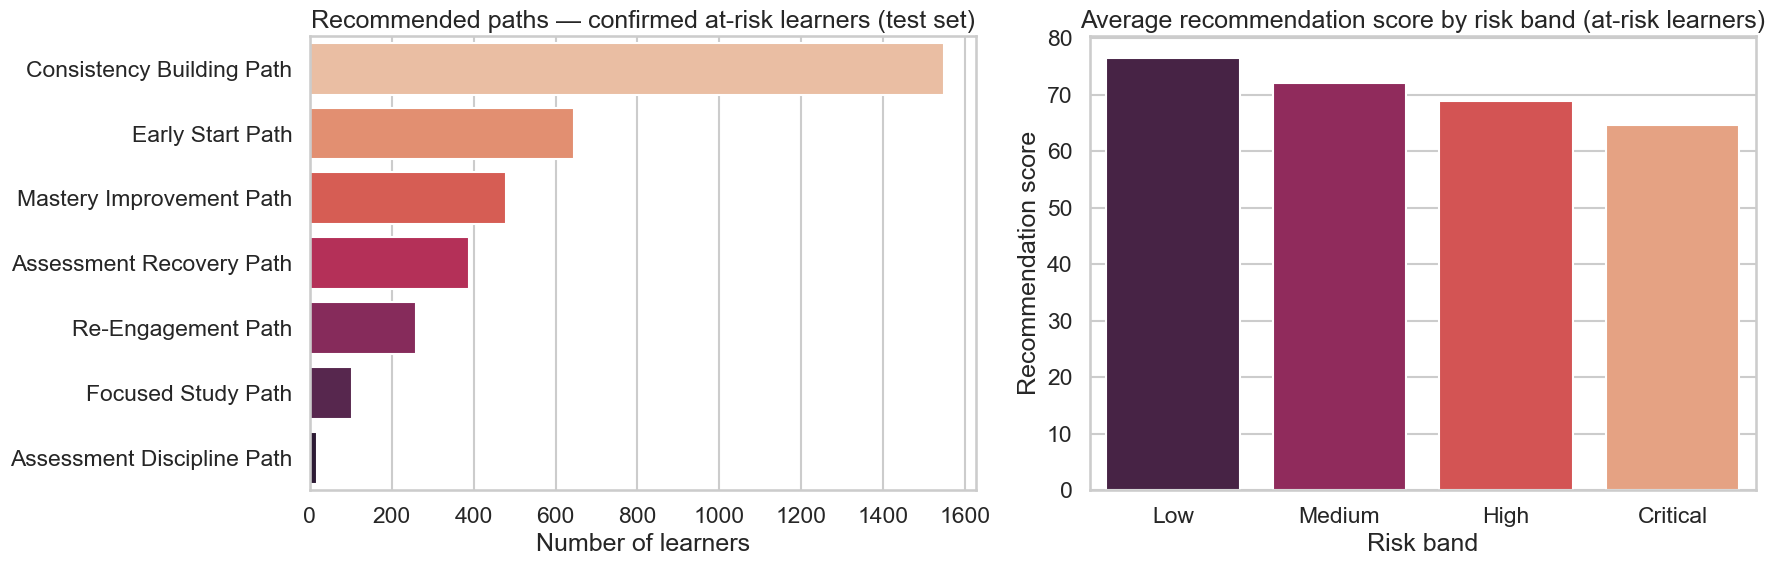

In [11]:
# At-risk intervention playbook — champion test set (XGBoost, day 30)
risk_preds = pd.read_csv(PROCESSED / 'risk_band_test_predictions.csv')

# True at-risk learners confirmed on the test set
at_risk_test = risk_preds.loc[risk_preds['y_true'].eq(1)].copy()
band_order = ['Low', 'Medium', 'High', 'Critical']
at_risk_test['risk_band'] = pd.Categorical(at_risk_test['risk_band'], categories=band_order, ordered=True)

# 1. Recommended path distribution by risk band
path_band = (
    at_risk_test.groupby(['risk_band', 'recommended_path'], observed=True)
    .size()
    .reset_index(name='count')
)
path_pivot = (
    path_band.pivot(index='recommended_path', columns='risk_band', values='count')
    .fillna(0).astype(int)
)
path_pivot = path_pivot[[c for c in band_order if c in path_pivot.columns]]
print('Recommended paths for at-risk learners (test set) by risk band:')
display(path_pivot)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: path distribution
path_counts = at_risk_test['recommended_path'].value_counts().reset_index()
path_counts.columns = ['recommended_path', 'count']
sns.barplot(data=path_counts, x='count', y='recommended_path', palette='rocket_r', ax=axes[0])
axes[0].set_title('Recommended paths — confirmed at-risk learners (test set)')
axes[0].set_xlabel('Number of learners')
axes[0].set_ylabel('')

# Plot 2: recommendation score by risk band
band_scores = (
    at_risk_test.groupby('risk_band', observed=True)['recommendation_score']
    .mean()
    .reindex(band_order)
    .reset_index()
)
sns.barplot(data=band_scores, x='risk_band', y='recommendation_score', palette='rocket', ax=axes[1])
axes[1].set_title('Average recommendation score by risk band (at-risk learners)')
axes[1].set_xlabel('Risk band')
axes[1].set_ylabel('Recommendation score')

plt.tight_layout()

# Top 3 intervention actions per risk band
print('\nTop intervention actions per risk band (at-risk learners):')
for band in band_order:
    sub = at_risk_test.loc[at_risk_test['risk_band'].eq(band), ['action_1', 'action_2', 'action_3']]
    actions = pd.concat([sub['action_1'], sub['action_2'], sub['action_3']], ignore_index=True)
    actions = actions.dropna().loc[lambda s: s.str.strip() != '']
    top = actions.value_counts().head(3)
    print(f'\n  [{band}]')
    for action, cnt in top.items():
        print(f'    ({cnt:>4d}x) {action}')

## 9. Export handoff

This notebook now exports the full research artifact set required by the upgraded plan:

- `model_horizon_comparison.csv`
- `threshold_search_by_horizon.csv`
- `selected_operating_points.csv`
- `champion_test_predictions.csv`
- `champion_test_metrics.csv`
- `ablation_results.csv`
- `ablation_gain_summary.csv`
- `calibration_summary.csv`
- `risk_band_summary.csv`
- `risk_band_test_predictions.csv`
- `model_feature_importance.csv`
- `error_analysis_samples.csv`

The project can now defend a stronger research narrative:
**early warning is time-sensitive, behavioral plus assessment features dominate weaker baselines, and probability calibration matters because intervention decisions depend on risk tiers rather than only hard class labels.**

## 10. Bootstrap Confidence Intervals for Champion Metrics

Single-point metrics on a fixed test set can be misleading without a measure of sampling variability.
This section uses **non-parametric bootstrap resampling** (1 000 iterations) on the champion test set to produce **95% confidence intervals** for all key metrics.

A narrow CI confirms stable champion metrics; a wide CI flags that the test set may be too small for firm conclusions.


,point_estimate,ci_95_lower,ci_95_upper,std
metric,,,,
precision,0.6276,0.6142,0.6415,0.0070
recall,0.9341,0.9262,0.9425,0.0042
f1,0.7508,0.7408,0.7617,0.0054
roc_auc,0.8477,0.8382,0.8569,0.0048
pr_auc,0.8767,0.8674,0.8869,0.0049


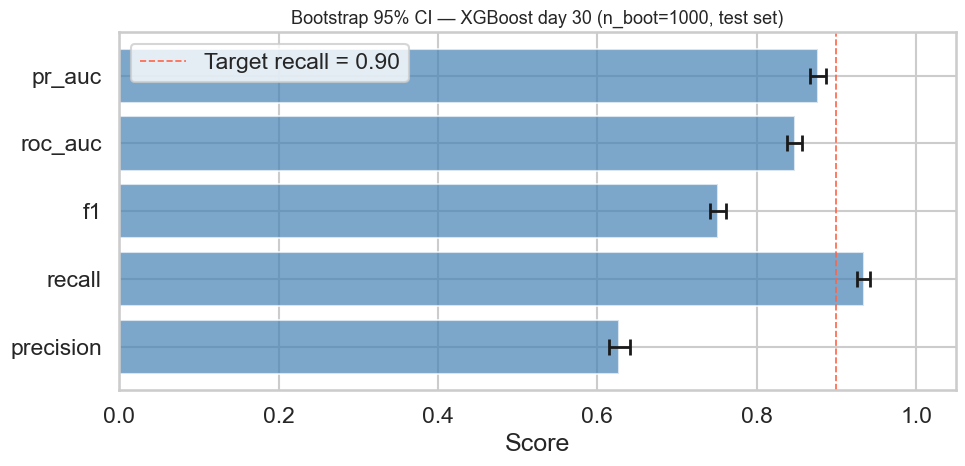

In [12]:
import numpy as np
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
)

_test_preds = pd.read_csv(PROCESSED / 'risk_band_test_predictions.csv')
_test_preds = _test_preds.dropna(subset=['y_true', 'y_pred', 'risk_probability']).reset_index(drop=True)

_y_true_b = _test_preds['y_true'].astype(int)
_y_pred_b = _test_preds['y_pred'].astype(int)
_y_prob_b = _test_preds['risk_probability'].astype(float).values

N_BOOT = 1_000
_rng = np.random.default_rng(seed=42)
_n = len(_y_true_b)

_boot_scores = {m: [] for m in ['precision', 'recall', 'f1', 'roc_auc', 'pr_auc']}
for _ in range(N_BOOT):
    _idx = _rng.integers(0, _n, size=_n)
    _yt = _y_true_b.iloc[_idx].values
    _yp = _y_pred_b.iloc[_idx].values
    _yprob = _y_prob_b[_idx]
    if _yt.sum() == 0 or _yt.sum() == _n:
        continue
    _boot_scores['precision'].append(precision_score(_yt, _yp, zero_division=0))
    _boot_scores['recall'].append(recall_score(_yt, _yp, zero_division=0))
    _boot_scores['f1'].append(f1_score(_yt, _yp, zero_division=0))
    _boot_scores['roc_auc'].append(roc_auc_score(_yt, _yprob))
    _boot_scores['pr_auc'].append(average_precision_score(_yt, _yprob))

_ci_rows = []
for _metric, _scores in _boot_scores.items():
    _arr = np.array(_scores)
    _ci_rows.append({
        'metric': _metric,
        'point_estimate': float(_arr.mean()),
        'ci_95_lower': float(np.percentile(_arr, 2.5)),
        'ci_95_upper': float(np.percentile(_arr, 97.5)),
        'std': float(_arr.std()),
    })

ci_table = pd.DataFrame(_ci_rows).set_index('metric').round(4)
display(ci_table)

fig, ax = plt.subplots(figsize=(10, 5))
_pt = ci_table['point_estimate']
_lo = _pt - ci_table['ci_95_lower']
_hi = ci_table['ci_95_upper'] - _pt
ax.barh(
    ci_table.index, _pt,
    xerr=[_lo, _hi],
    color='steelblue', alpha=0.7, capsize=6,
    error_kw={'elinewidth': 2, 'capthick': 2},
)
ax.axvline(0.90, color='tomato', linestyle='--', linewidth=1.2, label='Target recall = 0.90')
ax.set_title(
    f'Bootstrap 95% CI — XGBoost day {champion_horizon} '
    f'(n_boot={N_BOOT}, test set)',
    fontsize=13,
)
ax.set_xlabel('Score')
ax.set_xlim(0, 1.05)
ax.legend()
plt.tight_layout()


## 11. Fairness and Subgroup Analysis

A model achieving high **average** recall may still systematically miss specific demographic groups.
This section slices champion test-set performance across four observable dimensions:

| Dimension | Groups |
|---|---|
| Gender | Male vs Female |
| Deprivation index (IMD) | Low (10–40 %) vs High (70–100 %) |
| Disability status | Yes vs No |
| Prior attempts | First attempt vs Re-attempt |

A recall gap > 0.10 between groups of the same dimension warrants a closer look before the model is used for real interventions.


,subgroup,group,n,at_risk_rate,recall,precision,f1,roc_auc
0,Gender,Male,3602,0.5386,0.9335,0.6397,0.7592,0.8541
1,Gender,Female,2917,0.5149,0.9348,0.6136,0.7409,0.8397
2,Disability,Disability = Yes,655,0.6153,0.9702,0.6672,0.7907,0.8490
3,Disability,Disability = No,5864,0.5182,0.9293,0.6230,0.7459,0.8466
4,IMD (deprivation),Low (10–40 %),2111,0.5751,0.9539,0.6366,0.7636,0.8366
5,IMD (deprivation),High (70–100 %),1647,0.4681,0.8988,0.6047,0.7230,0.8501
6,Prior attempts,First attempt,5692,0.5088,0.9289,0.6175,0.7419,0.8540
7,Prior attempts,Re-attempt,827,0.6602,0.9615,0.6881,0.8021,0.7599


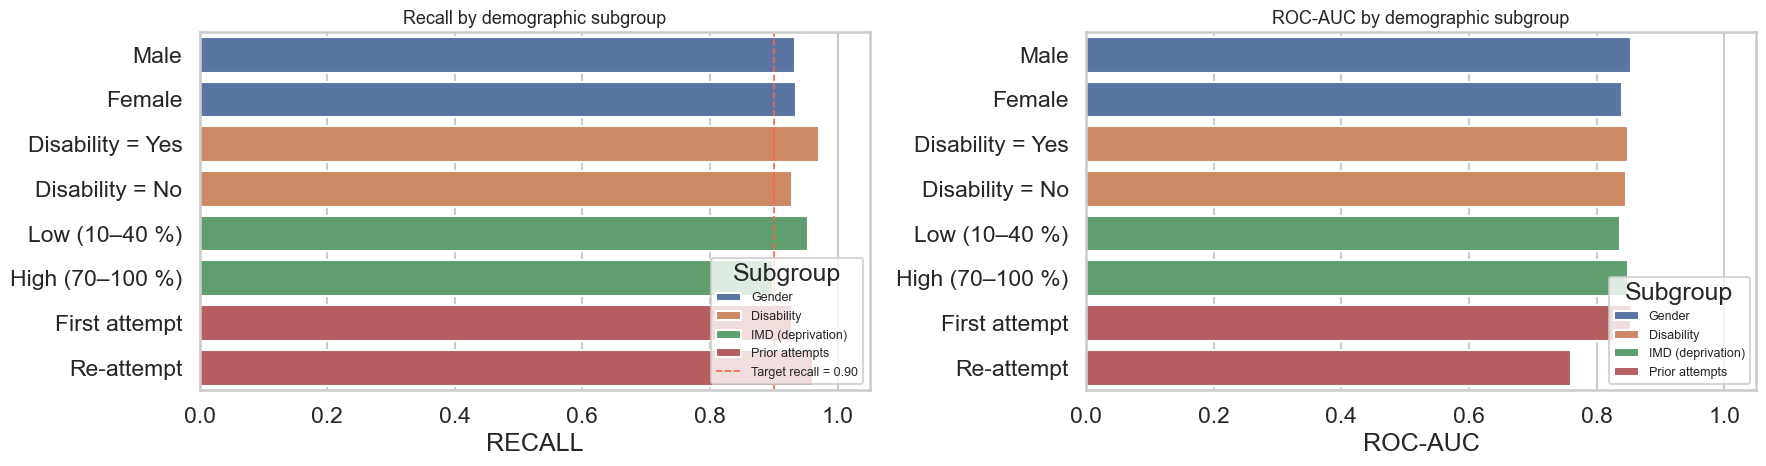

In [13]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

_KEY_F = ['id_student', 'code_module', 'code_presentation']
_test_preds_f = pd.read_csv(PROCESSED / 'risk_band_test_predictions.csv')
_day30_f = pd.read_csv(PROCESSED / 'features_prediction_day30.csv')

_demo_cols = [
    c for c in _day30_f.columns
    if c.startswith(('gender_', 'imd_band_', 'disability_', 'age_band_', 'num_of_prev_attempts'))
]
_merged_f = _test_preds_f.merge(_day30_f[_KEY_F + _demo_cols], on=_KEY_F, how='left')
_merged_f['y_true'] = _merged_f['y_true'].astype(int)
_merged_f['y_pred'] = _merged_f['y_pred'].astype(int)


def _subgroup_metrics(df, subgroup, label):
    if len(df) < 20 or df['y_true'].sum() == 0:
        return None
    yt = df['y_true'].values
    yp = df['y_pred'].values
    yprob = df['risk_probability'].astype(float).values
    return {
        'subgroup': subgroup,
        'group': label,
        'n': len(df),
        'at_risk_rate': round(float(yt.mean()), 4),
        'recall': round(float(recall_score(yt, yp, zero_division=0)), 4),
        'precision': round(float(precision_score(yt, yp, zero_division=0)), 4),
        'f1': round(float(f1_score(yt, yp, zero_division=0)), 4),
        'roc_auc': round(float(roc_auc_score(yt, yprob)), 4) if len(np.unique(yt)) > 1 else float('nan'),
    }


_fair_rows = []

# Gender
if 'gender_M' in _merged_f.columns:
    for _v, _lbl in [(1, 'Male'), (0, 'Female')]:
        _r = _subgroup_metrics(_merged_f.loc[_merged_f['gender_M'] == _v], 'Gender', _lbl)
        if _r:
            _fair_rows.append(_r)

# Disability
if 'disability_Y' in _merged_f.columns:
    for _v, _lbl in [(1, 'Disability = Yes'), (0, 'Disability = No')]:
        _r = _subgroup_metrics(_merged_f.loc[_merged_f['disability_Y'] == _v], 'Disability', _lbl)
        if _r:
            _fair_rows.append(_r)

# IMD deprivation index
_low_imd = [c for c in _merged_f.columns if c.startswith('imd_band_') and any(x in c for x in ['10-20', '20-30', '30-40'])]
_high_imd = [c for c in _merged_f.columns if c.startswith('imd_band_') and any(x in c for x in ['70-80', '80-90', '90-100'])]
if _low_imd:
    _r = _subgroup_metrics(_merged_f.loc[_merged_f[_low_imd].max(axis=1) == 1], 'IMD (deprivation)', 'Low (10–40 %)')
    if _r:
        _fair_rows.append(_r)
if _high_imd:
    _r = _subgroup_metrics(_merged_f.loc[_merged_f[_high_imd].max(axis=1) == 1], 'IMD (deprivation)', 'High (70–100 %)')
    if _r:
        _fair_rows.append(_r)

# Prior attempts
if 'num_of_prev_attempts' in _merged_f.columns:
    for _mask, _lbl in [
        (_merged_f['num_of_prev_attempts'] == 0, 'First attempt'),
        (_merged_f['num_of_prev_attempts'] >= 1, 'Re-attempt'),
    ]:
        _r = _subgroup_metrics(_merged_f.loc[_mask], 'Prior attempts', _lbl)
        if _r:
            _fair_rows.append(_r)

fairness_table = pd.DataFrame(_fair_rows)
display(fairness_table.round(4))

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
for ax, col in [(axes[0], 'recall'), (axes[1], 'roc_auc')]:
    sns.barplot(
        data=fairness_table, x=col, y='group', hue='subgroup',
        dodge=False, ax=ax,
    )
    if col == 'recall':
        ax.axvline(0.90, color='tomato', linestyle='--', linewidth=1.2, label='Target recall = 0.90')
        ax.legend(title='Subgroup', loc='lower right', fontsize=9)
    else:
        ax.legend(title='Subgroup', fontsize=9)
    ax.set_title(f'{"Recall" if col == "recall" else "ROC-AUC"} by demographic subgroup', fontsize=13)
    ax.set_xlabel(col.replace('_', '-').upper())
    ax.set_ylabel('')
    ax.set_xlim(0, 1.05)

plt.tight_layout()


## 12. Risk Trajectory Analysis (Day 7 → 14 → 21 → 30)

The four feature snapshots capture learner behaviour at increasing points in the course.
Plotting the **mean signal value across horizons** answers:

- **How quickly** do at-risk and non-at-risk groups diverge on behavioural features?
- **Which signals** show the clearest and earliest separation?

A feature that separates the groups at day 7 is a high-value *early-warning* candidate; one that only diverges at day 30 supports a *late-stage* intervention strategy.
The shaded bands show ±1 standard error of the mean.


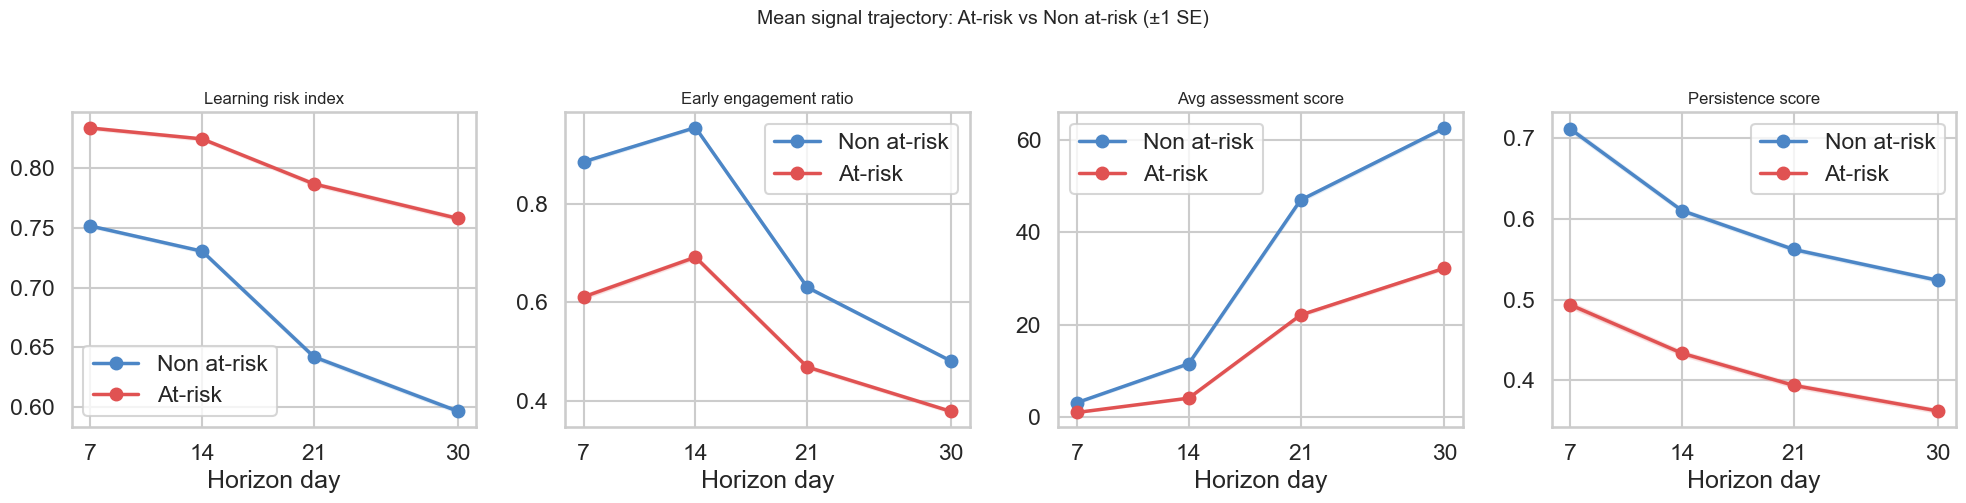

In [14]:
_TRAJ_FEATS = {
    'learning_risk_index': 'Learning risk index',
    'early_engagement_ratio': 'Early engagement ratio',
    'avg_score': 'Avg assessment score',
    'persistence_score': 'Persistence score',
}
_PALETTE_T = {'Non at-risk': '#4C86C6', 'At-risk': '#E05252'}

_traj_rows = []
for _h in HORIZONS:
    _hdf = pd.read_csv(PROCESSED / f'features_prediction_day{_h:02d}.csv')
    for _feat, _feat_lbl in _TRAJ_FEATS.items():
        if _feat not in _hdf.columns:
            continue
        for _rv, _grp in [(0, 'Non at-risk'), (1, 'At-risk')]:
            _vals = _hdf.loc[_hdf['at_risk'] == _rv, _feat].dropna()
            _traj_rows.append({
                'horizon_day': _h,
                'feature': _feat_lbl,
                'group': _grp,
                'mean': float(_vals.mean()),
                'sem': float(_vals.std() / max(len(_vals) ** 0.5, 1)),
                'n': len(_vals),
            })

traj_df = pd.DataFrame(_traj_rows)
_feats_in_data = [lbl for lbl in _TRAJ_FEATS.values() if lbl in traj_df['feature'].unique()]
_n_feats = len(_feats_in_data)

fig, axes = plt.subplots(1, _n_feats, figsize=(5 * _n_feats, 5), sharey=False)
if _n_feats == 1:
    axes = [axes]

for ax, feat in zip(axes, _feats_in_data):
    _sub = traj_df.loc[traj_df['feature'] == feat].copy()
    for grp, color in _PALETTE_T.items():
        _g = _sub.loc[_sub['group'] == grp].sort_values('horizon_day')
        ax.plot(_g['horizon_day'], _g['mean'], marker='o', linewidth=2.5, label=grp, color=color)
        ax.fill_between(
            _g['horizon_day'],
            _g['mean'] - _g['sem'],
            _g['mean'] + _g['sem'],
            alpha=0.15, color=color,
        )
    ax.set_title(feat, fontsize=12)
    ax.set_xlabel('Horizon day')
    ax.set_xticks(list(HORIZONS))
    ax.legend()

fig.suptitle('Mean signal trajectory: At-risk vs Non at-risk (±1 SE)', fontsize=14, y=1.02)
plt.tight_layout()


## 13. Threshold Cost-Benefit Analysis

The recall-first rule selects a threshold that meets recall ≥ 0.90.
But practitioners face a concrete resource question: **"If we can only contact _k_ learners per cohort, which threshold maximises true catches while minimising false alerts?"**

This section builds a cost-benefit table for the champion pair across the full threshold grid:

| Column | Meaning |
|---|---|
| `total_flagged` | Total learners the model would alert (TP + FP) |
| `flagged_pct` | Share of the validation cohort flagged |
| `false_alert_ratio` | FP per TP caught — lower is better |

The selected operating point (`threshold = 0.25`) is marked in every panel.


,threshold,recall,precision,f2,total_flagged,flagged_pct,tp,fp,fn,false_alert_ratio
0,0.0500,0.9985,0.5303,0.8487,6481,99.4000,3437,3044,5,0.8850
1,0.1000,0.9922,0.5429,0.8513,6290,96.5000,3415,2875,27,0.8420
2,0.1500,0.9811,0.5681,0.8566,5944,91.2000,3377,2567,65,0.7600
3,0.2000,0.9567,0.5981,0.8543,5506,84.5000,3293,2213,149,0.6720
4,0.2500,0.9250,0.6284,0.8452,5067,77.7000,3184,1883,258,0.5910
5,0.3000,0.8928,0.6623,0.8347,4640,71.2000,3073,1567,369,0.5100
6,0.3500,0.8556,0.6933,0.8173,4248,65.2000,2945,1303,497,0.4420
7,0.4000,0.8030,0.7258,0.7863,3808,58.4000,2764,1044,678,0.3780
8,0.4500,0.7510,0.7563,0.7521,3418,52.4000,2585,833,857,0.3220
9,0.5000,0.7051,0.7852,0.7198,3091,47.4000,2427,664,1015,0.2730


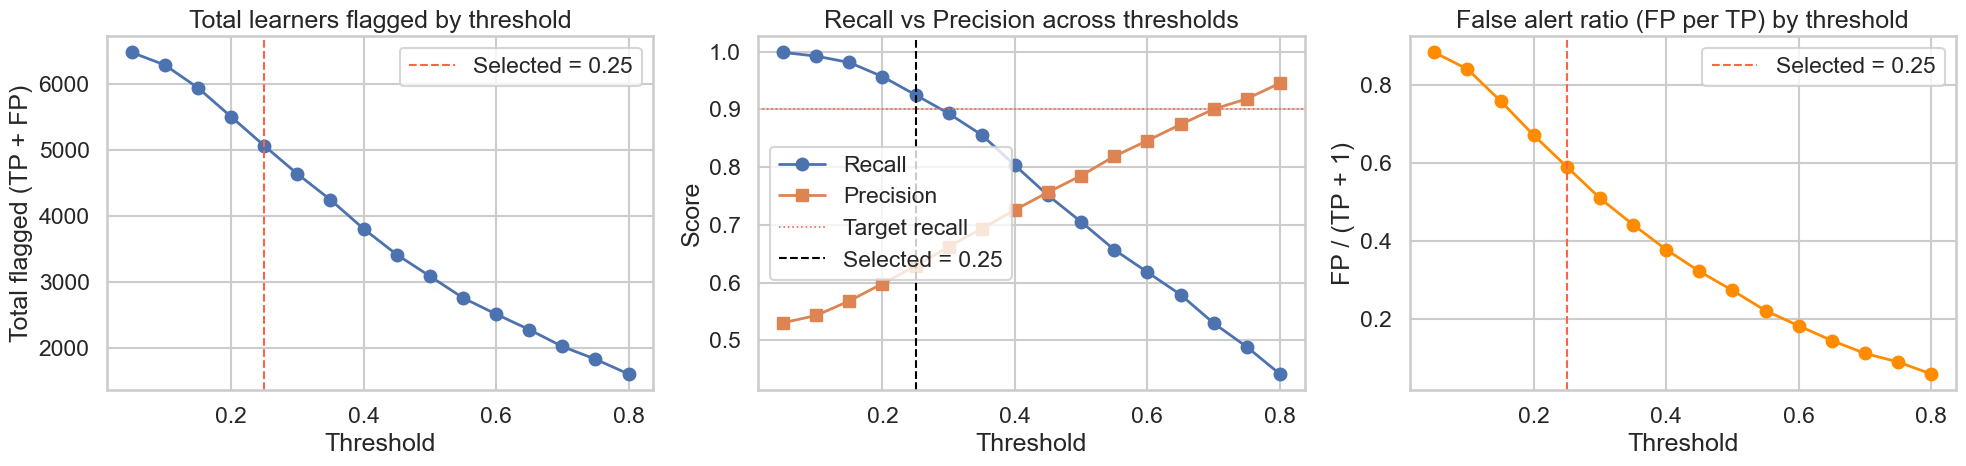

In [15]:
_thresh_search = pd.read_csv(PROCESSED / 'threshold_search_by_horizon.csv')
_champ_cb = _thresh_search.loc[
    (_thresh_search['horizon_day'] == champion_horizon)
    & (_thresh_search['model'] == champion_model)
].copy().sort_values('threshold').reset_index(drop=True)

_n_val = int(_champ_cb[['tp', 'fp', 'fn', 'tn']].iloc[0].sum())
_champ_cb['total_flagged'] = _champ_cb['tp'] + _champ_cb['fp']
_champ_cb['flagged_pct'] = (_champ_cb['total_flagged'] / _n_val * 100).round(1)
_champ_cb['false_alert_ratio'] = (_champ_cb['fp'] / (_champ_cb['tp'] + 1)).round(3)

_display_cols = [
    'threshold', 'recall', 'precision', 'f2',
    'total_flagged', 'flagged_pct', 'tp', 'fp', 'fn', 'false_alert_ratio',
]
display(_champ_cb[_display_cols].round(4))

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Panel 1 — total learners flagged
axes[0].plot(_champ_cb['threshold'], _champ_cb['total_flagged'], marker='o', linewidth=2)
axes[0].axvline(selected_threshold, color='tomato', linestyle='--', linewidth=1.5, label=f'Selected = {selected_threshold:.2f}')
axes[0].set_title('Total learners flagged by threshold')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Total flagged (TP + FP)')
axes[0].legend()

# Panel 2 — recall + precision
axes[1].plot(_champ_cb['threshold'], _champ_cb['recall'], marker='o', label='Recall', linewidth=2)
axes[1].plot(_champ_cb['threshold'], _champ_cb['precision'], marker='s', label='Precision', linewidth=2)
axes[1].axhline(0.90, color='tomato', linestyle=':', linewidth=1.2, label='Target recall')
axes[1].axvline(selected_threshold, color='black', linestyle='--', linewidth=1.5, label=f'Selected = {selected_threshold:.2f}')
axes[1].set_title('Recall vs Precision across thresholds')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Score')
axes[1].legend()

# Panel 3 — false alert ratio
axes[2].plot(_champ_cb['threshold'], _champ_cb['false_alert_ratio'], marker='o', color='darkorange', linewidth=2)
axes[2].axvline(selected_threshold, color='tomato', linestyle='--', linewidth=1.5, label=f'Selected = {selected_threshold:.2f}')
axes[2].set_title('False alert ratio (FP per TP) by threshold')
axes[2].set_xlabel('Threshold')
axes[2].set_ylabel('FP / (TP + 1)')
axes[2].legend()

plt.tight_layout()


## 14. SHAP Explainability (Champion Model Retrain)

SHAP (SHapley Additive exPlanations) provides **theoretically grounded** per-prediction feature attribution.
Unlike native XGBoost importance, SHAP values show the **direction** of each feature's effect and support **individual-level explanations** useful for advisor dashboards.

The champion XGBoost is retrained here with identical hyperparameters and the same `random_state=42` split.

- **Beeswarm plot** — global feature ranking with distribution of positive/negative impacts.
- **Mean |SHAP| table** — compact importace ranking for reports.
- **Waterfall plot** — explains one specific false negative (missed at-risk learner).

> **Requires:** `pip install shap`
> If the package is absent the cell falls back to native XGBoost feature importance.


XGBoost retrained: 19555 train / 6519 test samples.


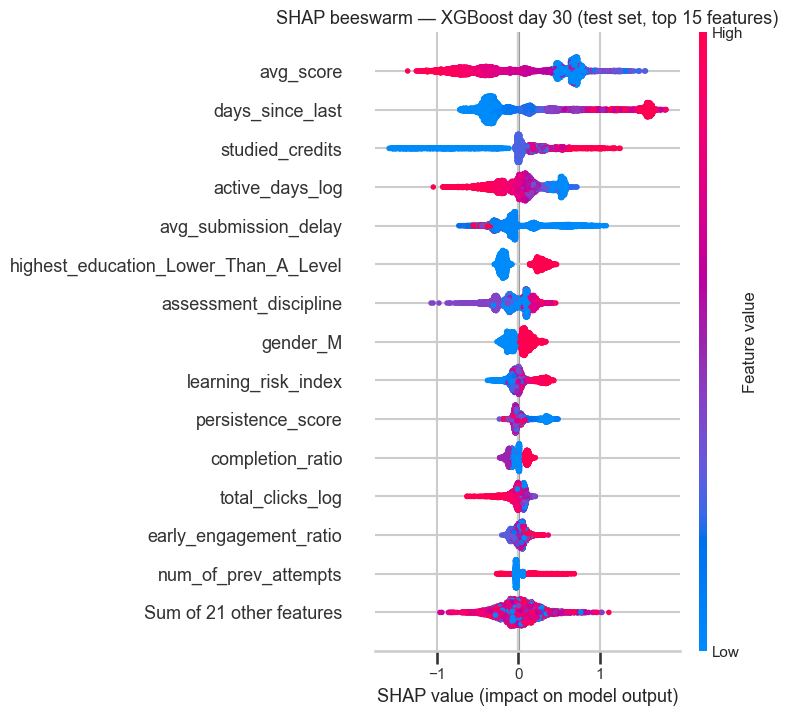


Top 15 features by mean |SHAP|:


,feature,mean_abs_shap
0,avg_score,0.5685
1,days_since_last,0.5637
2,studied_credits,0.2671
3,active_days_log,0.2319
4,avg_submission_delay,0.2298
5,highest_education_Lower Than A Level,0.2276
6,assessment_discipline,0.1628
7,gender_M,0.1061
8,learning_risk_index,0.0945
9,persistence_score,0.0895



Waterfall plot — false negative at test index 15 (missed at-risk learner):


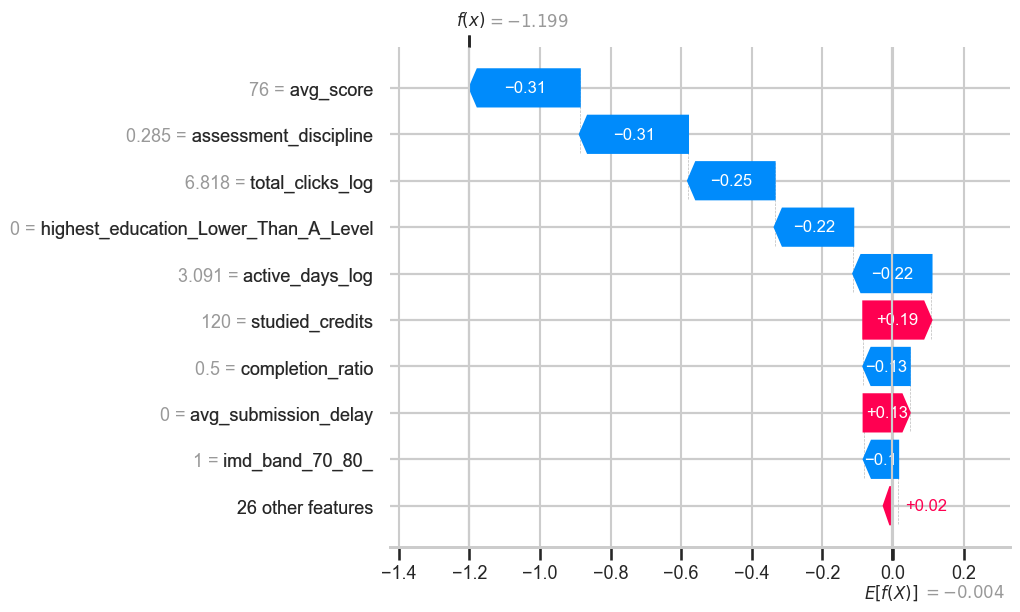

In [16]:
import re as _re_s
from sklearn.model_selection import train_test_split as _tts_shap
from xgboost import XGBClassifier as _XGBShap

try:
    import shap as _shap_lib
    _shap_ok = True
except ImportError:
    _shap_lib = None
    _shap_ok = False
    print(
        "shap not installed — falling back to XGBoost native importance.\n"
        "Install with:  pip install shap"
    )

# Retrain champion XGBoost with identical config and split
_KEY_S = ['id_student', 'code_module', 'code_presentation']
_TARGET_S = 'at_risk'

_stu_s = pd.read_csv(PROCESSED / 'student_info_clean.csv', low_memory=False)
_d30_s = pd.read_csv(PROCESSED / 'features_prediction_day30.csv')

_split_src_s = _stu_s[_KEY_S + ['final_result']].copy()
_split_src_s[_TARGET_S] = _split_src_s['final_result'].isin(['Fail', 'Withdrawn']).astype(int)
_tv_s, _te_s = _tts_shap(_split_src_s, test_size=0.20, stratify=_split_src_s[_TARGET_S], random_state=42)
_tr_s, _ = _tts_shap(_tv_s, test_size=0.25, stratify=_tv_s[_TARGET_S], random_state=42)

_split_map_s = pd.concat(
    [_tr_s[_KEY_S].assign(split='train'), _te_s[_KEY_S].assign(split='test')],
    ignore_index=True,
)
_mod_s = _d30_s.merge(_split_map_s, on=_KEY_S, how='inner')
_drop_s = _KEY_S + ['horizon_day', _TARGET_S, 'split']
_feat_cols_s = [c for c in _mod_s.columns if c not in _drop_s]

# Sanitize feature names: XGBoost forbids [ ] < in column names
_sanitize_map_s = {c: _re_s.sub(r'[^0-9a-zA-Z_]+', '_', c) for c in _feat_cols_s}
_reverse_map_s = {v: k for k, v in _sanitize_map_s.items()}
_feat_cols_clean_s = [_sanitize_map_s[c] for c in _feat_cols_s]

_X_s = _mod_s[_feat_cols_s].astype('float32').rename(columns=_sanitize_map_s)
_y_s = _mod_s[_TARGET_S].astype(int)
_splits_s = _mod_s['split']
_X_tr_s = _X_s.loc[_splits_s == 'train']
_X_te_s = _X_s.loc[_splits_s == 'test']
_y_tr_s = _y_s.loc[_splits_s == 'train']
_y_te_s = _y_s.loc[_splits_s == 'test']

_spw_s = float(_y_tr_s.eq(0).sum() / max(_y_tr_s.eq(1).sum(), 1))
_xgb_s = _XGBShap(
    n_estimators=350, max_depth=4, learning_rate=0.05,
    subsample=0.80, colsample_bytree=0.80,
    scale_pos_weight=_spw_s, min_child_weight=2,
    reg_lambda=1.5, objective='binary:logistic',
    eval_metric='logloss', tree_method='hist',
    random_state=42, n_jobs=4,
)
_xgb_s.fit(_X_tr_s, _y_tr_s)
print(f"XGBoost retrained: {len(_X_tr_s)} train / {len(_X_te_s)} test samples.")

if _shap_ok:
    _explainer_s = _shap_lib.TreeExplainer(_xgb_s)
    _shap_exp_s = _explainer_s(_X_te_s)

    # Beeswarm summary plot
    plt.figure(figsize=(10, 8))
    try:
        _shap_lib.plots.beeswarm(_shap_exp_s, max_display=15, show=False)
    except Exception:
        _shap_lib.summary_plot(
            _shap_exp_s.values, _X_te_s,
            feature_names=[_reverse_map_s.get(c, c) for c in _feat_cols_clean_s],
            max_display=15, show=False,
        )
    plt.title('SHAP beeswarm — XGBoost day 30 (test set, top 15 features)', fontsize=13)
    plt.tight_layout()
    plt.show()

    # Mean |SHAP| importance table — map back to original names
    _shap_imp_s = pd.DataFrame({
        'feature': [_reverse_map_s.get(c, c) for c in _feat_cols_clean_s],
        'mean_abs_shap': np.abs(_shap_exp_s.values).mean(axis=0),
    }).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)
    print("\nTop 15 features by mean |SHAP|:")
    display(_shap_imp_s.head(15))

    # Waterfall for the first false negative (missed at-risk learner)
    _y_pred_s = (_xgb_s.predict_proba(_X_te_s)[:, 1] >= 0.25).astype(int)
    _fn_mask_s = (_y_te_s.values == 1) & (_y_pred_s == 0)
    if _fn_mask_s.any():
        _fn_idx_s = int(np.where(_fn_mask_s)[0][0])
        print(f"\nWaterfall plot — false negative at test index {_fn_idx_s} (missed at-risk learner):")
        try:
            _shap_lib.plots.waterfall(_shap_exp_s[_fn_idx_s])
        except Exception:
            print("Waterfall plot requires shap >= 0.40.")
else:
    # Fallback: native XGBoost importance — map back to original names
    _imp_fallback = pd.DataFrame({
        'feature': [_reverse_map_s.get(c, c) for c in _feat_cols_clean_s],
        'importance': _xgb_s.feature_importances_,
    }).sort_values('importance', ascending=False).head(15).reset_index(drop=True)
    display(_imp_fallback)

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(
        data=_imp_fallback.sort_values('importance'),
        x='importance', y='feature', palette='Blues_r', ax=ax,
    )
    ax.set_title(
        'XGBoost native feature importance — day 30 retrain\n'
        '(install shap for SHAP values)',
        fontsize=13,
    )
    ax.set_xlabel('Importance')
    ax.set_ylabel('')
    plt.tight_layout()
